# Bootstrap — Intervalos de Confiança 95%
Estima a incerteza das métricas via reamostramento com reposição do conjunto de teste (2024).
Método: percentil (2.5% e 97.5% da distribuição bootstrap).
**Métricas:** Sensibilidade · AUPRC · ROC-AUC

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, average_precision_score, roc_auc_score
)

OUTPUT_MET  = '../../output/metricas'
OUTPUT_PLT  = '../../output/plots'
N_BOOTSTRAP = 1000
RANDOM_STATE = 42
os.makedirs(OUTPUT_PLT, exist_ok=True)

LABEL_MAP = {
    'logistic_regression_baseline':          'LR',
    'logistic_regression_baseline_tuned':    'LR (tuned)',
    'logistic_regression_smote_1_1':         'LR + SMOTE 1:1',
    'logistic_regression_smote_1_5':         'LR + SMOTE 1:5',
    'logistic_regression_smote_1_10':        'LR + SMOTE 1:10',
    'mlp_baseline':                          'MLP',
    'mlp_baseline_tuned':                    'MLP (tuned)',
    'lightgbm_baseline':                     'LightGBM',
    'lightgbm_baseline_tuned':               'LightGBM (tuned)',
    'xgboost_baseline':                      'XGBoost',
    'xgboost_baseline_tuned':               'XGBoost (tuned)',
    'random_forest_baseline':                'Random Forest',
    'random_forest_baseline_tuned':          'Random Forest (tuned)',
    'ensemble_lr_lr_tuned_mlp_lgbm_tuned':   'Ensemble (LR+MLP+LGBM)',
}

## 1. Carregamento das predições

In [2]:
predicoes = {}
for f in sorted(os.listdir(OUTPUT_MET)):
    if not f.endswith('_predicoes.parquet'):
        continue
    base = f.replace('_predicoes.parquet', '')
    df   = pd.read_parquet(os.path.join(OUTPUT_MET, f))
    predicoes[base] = {
        'label':   LABEL_MAP.get(base, base),
        'y_true':  df['y_true'].values,
        'y_proba': df['y_proba'].values,
    }

print(f'{len(predicoes)} modelos carregados:')
for k, v in predicoes.items():
    print(f'  {v["label"]:<35} n={len(v["y_true"]):,}  óbitos={v["y_true"].sum():,}')

11 modelos carregados:
  Ensemble (LR+MLP+LGBM)              n=160,534  óbitos=5,295.0
  LightGBM                            n=160,534  óbitos=5,295.0
  LightGBM (tuned)                    n=160,534  óbitos=5,295.0
  LR                                  n=160,534  óbitos=5,295.0
  LR (tuned)                          n=160,534  óbitos=5,295.0
  MLP                                 n=160,534  óbitos=5,295.0
  MLP (tuned)                         n=160,534  óbitos=5,295.0
  Random Forest                       n=160,534  óbitos=5,295.0
  Random Forest (tuned)               n=160,534  óbitos=5,295.0
  XGBoost                             n=160,534  óbitos=5,295.0
  XGBoost (tuned)                     n=160,534  óbitos=5,295.0


## 2. Função de bootstrap

In [3]:
def bootstrap_metricas(y_true, y_proba, n=N_BOOTSTRAP, seed=RANDOM_STATE):
    rng  = np.random.default_rng(seed)
    size = len(y_true)
    sens_list, auprc_list, roc_list = [], [], []

    while len(sens_list) < n:
        idx = rng.integers(0, size, size=size)
        yt  = y_true[idx]
        yp  = y_proba[idx]

        # descarta amostras degeneradas (apenas uma classe)
        if yt.sum() == 0 or yt.sum() == len(yt):
            continue

        tn, fp, fn, tp = confusion_matrix(yt, (yp >= 0.5).astype(int)).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        sens_list.append(sens)
        auprc_list.append(average_precision_score(yt, yp))
        roc_list.append(roc_auc_score(yt, yp))

    return pd.DataFrame({
        'sensibilidade': sens_list,
        'auprc':         auprc_list,
        'roc_auc':       roc_list,
    })

## 3. Execução do bootstrap (≈ alguns minutos)

In [4]:
resultados_bs = {}

for arquivo, info in predicoes.items():
    print(f'Bootstrap: {info["label"]}...', end=' ', flush=True)
    dist = bootstrap_metricas(info['y_true'], info['y_proba'])
    resultados_bs[arquivo] = dist
    print('OK')

print(f'\nConcluído — {N_BOOTSTRAP} iterações por modelo.')

Bootstrap: Ensemble (LR+MLP+LGBM)... OK
Bootstrap: LightGBM... OK
Bootstrap: LightGBM (tuned)... OK
Bootstrap: LR... OK
Bootstrap: LR (tuned)... OK
Bootstrap: MLP... OK
Bootstrap: MLP (tuned)... OK
Bootstrap: Random Forest... OK
Bootstrap: Random Forest (tuned)... OK
Bootstrap: XGBoost... OK
Bootstrap: XGBoost (tuned)... OK

Concluído — 1000 iterações por modelo.


## 4. Tabela de IC 95%

In [5]:
rows = []
for arquivo, dist in resultados_bs.items():
    info = predicoes[arquivo]
    y_true, y_proba = info['y_true'], info['y_proba']

    # estimativa pontual (conjunto completo)
    tn, fp, fn, tp = confusion_matrix(y_true, (y_proba >= 0.5).astype(int)).ravel()
    sens_pt  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    auprc_pt = average_precision_score(y_true, y_proba)
    roc_pt   = roc_auc_score(y_true, y_proba)

    for metrica, pt in [('sensibilidade', sens_pt), ('auprc', auprc_pt), ('roc_auc', roc_pt)]:
        lo = dist[metrica].quantile(0.025)
        hi = dist[metrica].quantile(0.975)
        rows.append({
            'modelo':   info['label'],
            'metrica':  metrica,
            'estimativa': round(pt, 4),
            'ic_low':   round(lo, 4),
            'ic_high':  round(hi, 4),
            'ic_width': round(hi - lo, 4),
        })

df_ic = pd.DataFrame(rows)

# tabela pivotada por métrica
for metrica in ['sensibilidade', 'auprc', 'roc_auc']:
    sub = (
        df_ic[df_ic['metrica'] == metrica]
        .sort_values('estimativa', ascending=False)
        [['modelo', 'estimativa', 'ic_low', 'ic_high', 'ic_width']]
        .reset_index(drop=True)
    )
    sub['IC 95%'] = sub.apply(lambda r: f"[{r['ic_low']:.4f}, {r['ic_high']:.4f}]", axis=1)
    print(f'\n=== {metrica.upper()} ===')
    display(sub[['modelo', 'estimativa', 'IC 95%', 'ic_width']])


=== SENSIBILIDADE ===


,modelo,estimativa,IC 95%,ic_width
0,LR (tuned),0.8008,"[0.7904, 0.8108]",0.0204
1,LR,0.8004,"[0.7901, 0.8105]",0.0204
2,XGBoost (tuned),0.7932,"[0.7822, 0.8044]",0.0222
3,Ensemble (LR+MLP+LGBM),0.7843,"[0.7733, 0.7944]",0.0210
4,MLP,0.7843,"[0.7740, 0.7954]",0.0214
5,MLP (tuned),0.7664,"[0.7551, 0.7771]",0.0220
6,LightGBM (tuned),0.7549,"[0.7440, 0.7659]",0.0219
7,XGBoost,0.7490,"[0.7373, 0.7606]",0.0232
8,LightGBM,0.6820,"[0.6697, 0.6941]",0.0245
9,Random Forest,0.6240,"[0.6105, 0.6360]",0.0255



=== AUPRC ===


,modelo,estimativa,IC 95%,ic_width
0,Ensemble (LR+MLP+LGBM),0.6472,"[0.6329, 0.6586]",0.0257
1,MLP,0.6369,"[0.6219, 0.6497]",0.0278
2,XGBoost (tuned),0.6314,"[0.6167, 0.6431]",0.0264
3,LightGBM (tuned),0.6294,"[0.6154, 0.6416]",0.0262
4,Random Forest,0.6276,"[0.6132, 0.6399]",0.0267
5,MLP (tuned),0.6272,"[0.6119, 0.6404]",0.0286
6,Random Forest (tuned),0.6268,"[0.6120, 0.6386]",0.0265
7,LR,0.6250,"[0.6095, 0.6384]",0.0289
8,LR (tuned),0.6250,"[0.6096, 0.6383]",0.0287
9,XGBoost,0.6112,"[0.5961, 0.6233]",0.0271



=== ROC_AUC ===


,modelo,estimativa,IC 95%,ic_width
0,Ensemble (LR+MLP+LGBM),0.9261,"[0.9219, 0.9302]",0.0083
1,LR (tuned),0.9242,"[0.9201, 0.9283]",0.0082
2,LR,0.9242,"[0.9200, 0.9283]",0.0082
3,MLP,0.9217,"[0.9172, 0.9260]",0.0088
4,Random Forest,0.9209,"[0.9164, 0.9250]",0.0085
5,XGBoost (tuned),0.9194,"[0.9148, 0.9238]",0.0090
6,MLP (tuned),0.9157,"[0.9111, 0.9202]",0.0091
7,LightGBM (tuned),0.9136,"[0.9089, 0.9180]",0.0091
8,XGBoost,0.9098,"[0.9051, 0.9145]",0.0094
9,Random Forest (tuned),0.9038,"[0.8988, 0.9087]",0.0099


## 5. Forest plot — IC 95% por métrica

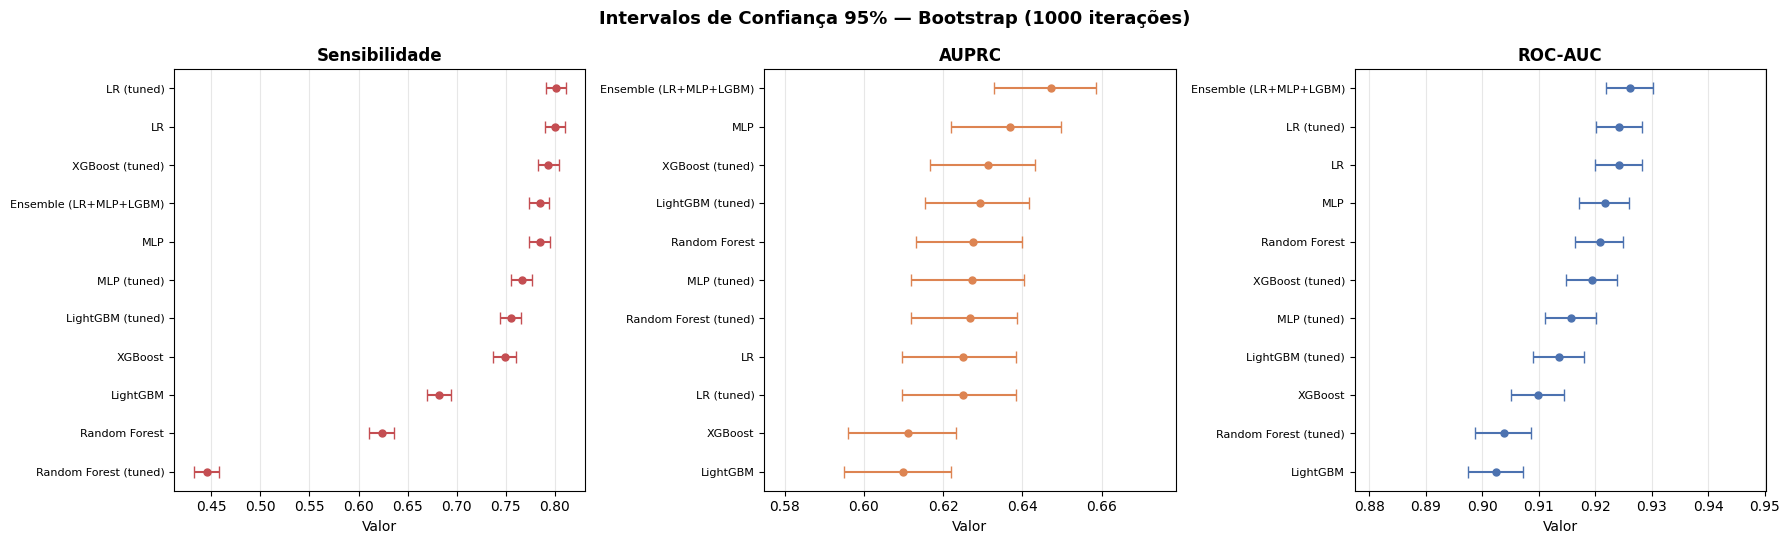

In [6]:
metricas_plot = [
    ('sensibilidade', '#C44E52', 'Sensibilidade'),
    ('auprc',         '#DD8452', 'AUPRC'),
    ('roc_auc',       '#4C72B0', 'ROC-AUC'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, max(5, len(predicoes) * 0.5)))

for ax, (metrica, cor, titulo) in zip(axes, metricas_plot):
    sub = (
        df_ic[df_ic['metrica'] == metrica]
        .sort_values('estimativa', ascending=True)
        .reset_index(drop=True)
    )
    y_pos = np.arange(len(sub))

    xerr_lo = sub['estimativa'] - sub['ic_low']
    xerr_hi = sub['ic_high']   - sub['estimativa']

    ax.errorbar(
        sub['estimativa'], y_pos,
        xerr=[xerr_lo, xerr_hi],
        fmt='o', color=cor, ecolor=cor, elinewidth=1.5,
        capsize=4, markersize=5,
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub['modelo'], fontsize=8)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(
        max(0, sub['ic_low'].min() - 0.02),
        min(1, sub['ic_high'].max() + 0.02),
    )

plt.suptitle(f'Intervalos de Confiança 95% — Bootstrap ({N_BOOTSTRAP} iterações)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'bootstrap_forest_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Distribuição bootstrap — top modelos

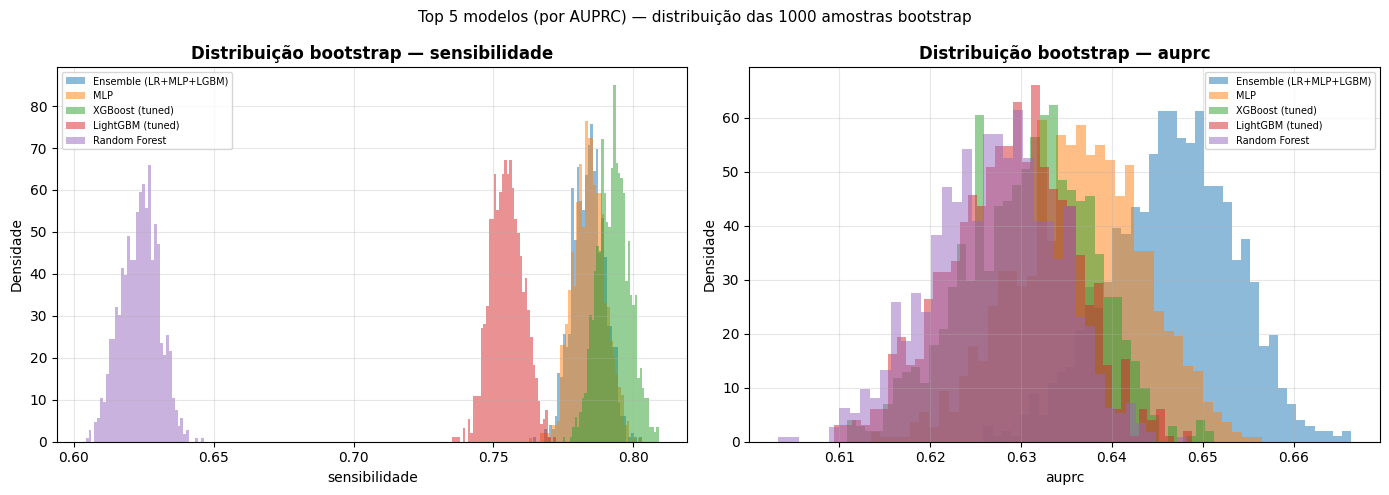

In [7]:
# Seleciona top 5 por AUPRC para visualizar a distribuição
top5 = (
    df_ic[df_ic['metrica'] == 'auprc']
    .sort_values('estimativa', ascending=False)
    .head(5)['modelo']
    .tolist()
)

arquivo_por_label = {v['label']: k for k, v in predicoes.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metrica in zip(axes, ['sensibilidade', 'auprc']):
    for label in top5:
        arq  = arquivo_por_label[label]
        dist = resultados_bs[arq][metrica]
        ax.hist(dist, bins=40, alpha=0.5, label=label, density=True)
    ax.set_title(f'Distribuição bootstrap — {metrica}', fontweight='bold')
    ax.set_xlabel(metrica)
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle(f'Top 5 modelos (por AUPRC) — distribuição das {N_BOOTSTRAP} amostras bootstrap',
             fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'bootstrap_distribuicoes.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparação pareada — sobreposição de ICs
Dois modelos são considerados **estatisticamente distinguíveis** se seus ICs 95% não se sobrepõem (teste conservador).

In [8]:
from itertools import combinations

for metrica in ['sensibilidade', 'auprc']:
    sub = df_ic[df_ic['metrica'] == metrica].set_index('modelo')
    modelos_ord = sub.sort_values('estimativa', ascending=False).index.tolist()

    print(f'\n=== Diferenças significativas — {metrica.upper()} ===')
    encontrou = False
    for m1, m2 in combinations(modelos_ord, 2):
        lo1, hi1 = sub.loc[m1, 'ic_low'], sub.loc[m1, 'ic_high']
        lo2, hi2 = sub.loc[m2, 'ic_low'], sub.loc[m2, 'ic_high']
        # ICs não se sobrepõem
        if hi1 < lo2 or hi2 < lo1:
            est1, est2 = sub.loc[m1, 'estimativa'], sub.loc[m2, 'estimativa']
            melhor = m1 if est1 > est2 else m2
            print(f'  {m1} vs {m2} → distinguíveis (melhor: {melhor})')
            encontrou = True
    if not encontrou:
        print('  Nenhum par com ICs não sobrepostos — diferenças não são estatisticamente distinguíveis.')


=== Diferenças significativas — SENSIBILIDADE ===
  LR (tuned) vs MLP (tuned) → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs LightGBM (tuned) → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs XGBoost → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs LightGBM → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs Random Forest → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs Random Forest (tuned) → distinguíveis (melhor: LR (tuned))
  LR vs MLP (tuned) → distinguíveis (melhor: LR)
  LR vs LightGBM (tuned) → distinguíveis (melhor: LR)
  LR vs XGBoost → distinguíveis (melhor: LR)
  LR vs LightGBM → distinguíveis (melhor: LR)
  LR vs Random Forest → distinguíveis (melhor: LR)
  LR vs Random Forest (tuned) → distinguíveis (melhor: LR)
  XGBoost (tuned) vs MLP (tuned) → distinguíveis (melhor: XGBoost (tuned))
  XGBoost (tuned) vs LightGBM (tuned) → distinguíveis (melhor: XGBoost (tuned))
  XGBoost (tuned) vs XGBoost → distinguíveis (melhor: XGBoost (tuned))
  XGBoost (tuned) v

## 8. Salvamento

In [9]:
os.makedirs(OUTPUT_MET, exist_ok=True)

# Resumo dos ICs
ic_path = os.path.join(OUTPUT_MET, 'bootstrap_ic95.csv')
df_ic.to_csv(ic_path, index=False)
print(f'ICs salvos: {ic_path}')

# Distribuições brutas (1 linha por iteração por modelo)
dist_rows = []
for arquivo, dist in resultados_bs.items():
    df_temp = dist.copy()
    df_temp['modelo'] = predicoes[arquivo]['label']
    dist_rows.append(df_temp)

df_dist = pd.concat(dist_rows, ignore_index=True)
dist_path = os.path.join(OUTPUT_MET, 'bootstrap_distribuicoes.parquet')
df_dist.to_parquet(dist_path, index=False)
print(f'Distribuições salvas: {dist_path} ({len(df_dist):,} linhas)')

ICs salvos: ../../output/metricas/bootstrap_ic95.csv
Distribuições salvas: ../../output/metricas/bootstrap_distribuicoes.parquet (11,000 linhas)
